In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Salary Data.csv")

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.shape

(375, 6)

In [6]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


In [8]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [9]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(50)

In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(49)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(324, 6)

Exploratory Data Analysis (EDA)|

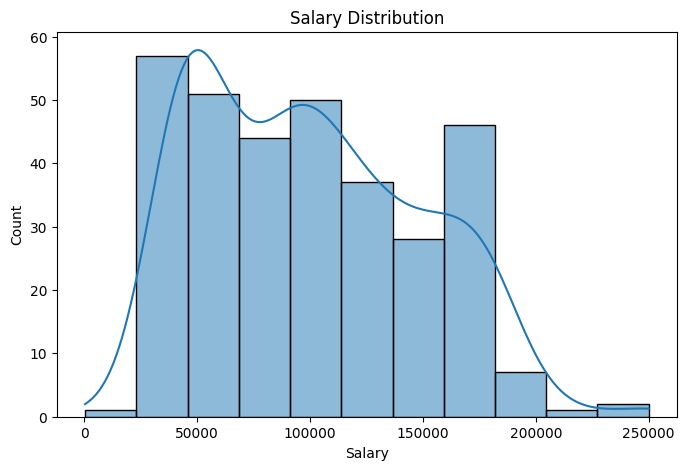

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df['Salary'], kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

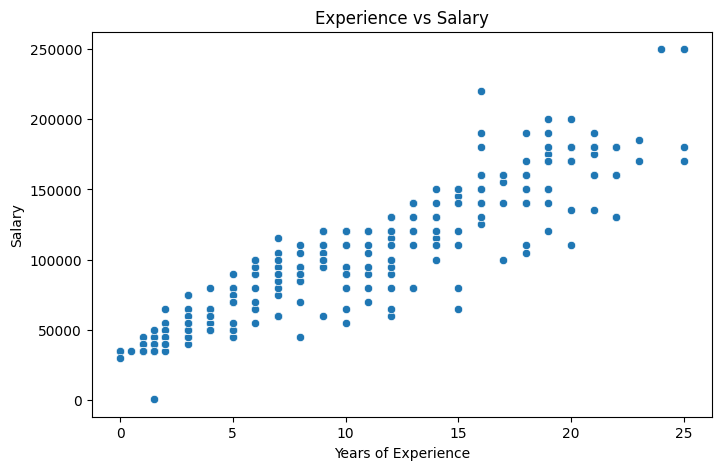

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Years of Experience'],
    y=df['Salary']
)

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

In [24]:
df.corr(numeric_only=True)

,Age,Years of Experience,Salary
Age,1.000000,0.979192,0.916543
Years of Experience,0.979192,1.000000,0.924455
Salary,0.916543,0.924455,1.000000


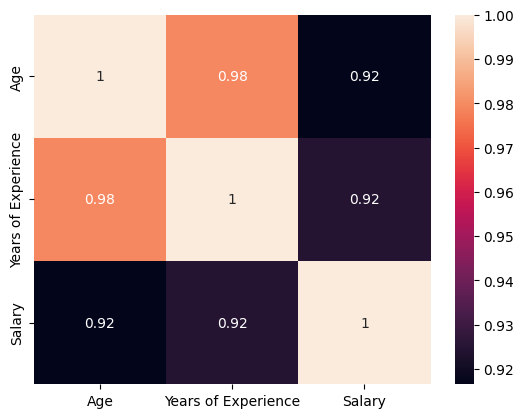

In [25]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

Feature Engineering + Encoding means text ko numbers m convert karna

In [30]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [31]:
df.dtypes

Age                    float64
Gender                     str
Education Level            str
Job Title                  str
Years of Experience    float64
Salary                 float64
dtype: object

In [32]:
#separate the categorial column

categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

C:\Users\HP\AppData\Local\Temp\ipykernel_5472\2921613792.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


Index(['Gender', 'Education Level', 'Job Title'], dtype='str')

In [33]:
# Encoding Apply

from sklearn.preprocessing import LabelEncoder

In [34]:
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [36]:
# Checking Encoding 
 
df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [43]:
#X and Y creating

X = df.drop("Salary", axis=1)

y = df["Salary"]

In [44]:
X.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,0,159,5.0
1,28.0,0,1,17,3.0
2,45.0,1,2,130,15.0
3,36.0,0,0,101,7.0
4,52.0,1,1,22,20.0


In [45]:
y.head()

0     90000.0
1     65000.0
2    150000.0
3     60000.0
4    200000.0
Name: Salary, dtype: float64

In [46]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
print(X_train.shape)
print(X_test.shape)

(259, 5)
(65, 5)


In [47]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression


In [ ]:
# Create model

lr_model = LinearRegression()

In [49]:
# Model Train

lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 2812.91, 7389.08,15422.74, 19.58, 2892.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Age','Gender','Education Level','Job Title','Years of Experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.824e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [51]:
#Prediction

y_pred_lr = lr_model.predict(X_test)

In [54]:
#|Evaluation Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [55]:
mae = mean_absolute_error(y_test, y_pred_lr)

mse = mean_squared_error(y_test, y_pred_lr)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_lr)


print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 10570.786401136189
RMSE: 14344.132449097837
R2 Score: 0.8911231066517087


In [57]:
#Decision Tree

from sklearn.tree import DecisionTreeRegressor



In [58]:
#Create Model 

dt_model = DecisionTreeRegressor(
    random_state=42
)

In [59]:
#Train

dt_model.fit(X_train, y_train)



,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [60]:
#Predict

y_pred_dt = dt_model.predict(X_test)

In [62]:
#Evaluate

dt_mae = mean_absolute_error(y_test, y_pred_dt)

dt_mse = mean_squared_error(y_test, y_pred_dt)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, y_pred_dt)


print("MAE:", dt_mae)

print("RMSE:", dt_rmse)

print("R2 Score:", dt_r2)

MAE: 12538.461538461539
RMSE: 17661.344142592232
R2 Score: 0.8349427317189252


In [63]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

In [65]:
#Model Create
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [66]:
#Train

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [67]:
#Prediction

y_pred_rf = rf_model.predict(X_test)

In [68]:
#Evaluation

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_mse = mean_squared_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, y_pred_rf)


print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 9317.23076923077
RMSE: 12684.587070291387
R2 Score: 0.9148587906175745


In [70]:
#Model Comparison Table

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score": [
        r2,
        dt_r2,
        rf_r2
    ],

    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],

    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ]
})

model_results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.891123,10570.786401,14344.132449
1,Decision Tree,0.834943,12538.461538,17661.344143
2,Random Forest,0.914859,9317.230769,12684.587070


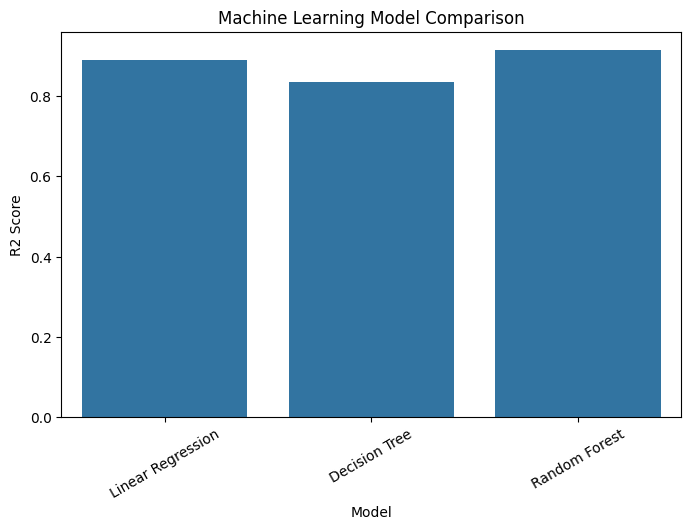

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=model_results
)

plt.title("Machine Learning Model Comparison")

plt.xticks(rotation=30)

plt.show()

In [73]:
#Feature Importance Analysis

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance

,Feature,Importance
0,Age,0.330297
1,Gender,0.002931
2,Education Level,0.030731
3,Job Title,0.124331
4,Years of Experience,0.511709


In [74]:
#sort 
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Years of Experience,0.511709
0,Age,0.330297
3,Job Title,0.124331
2,Education Level,0.030731
1,Gender,0.002931


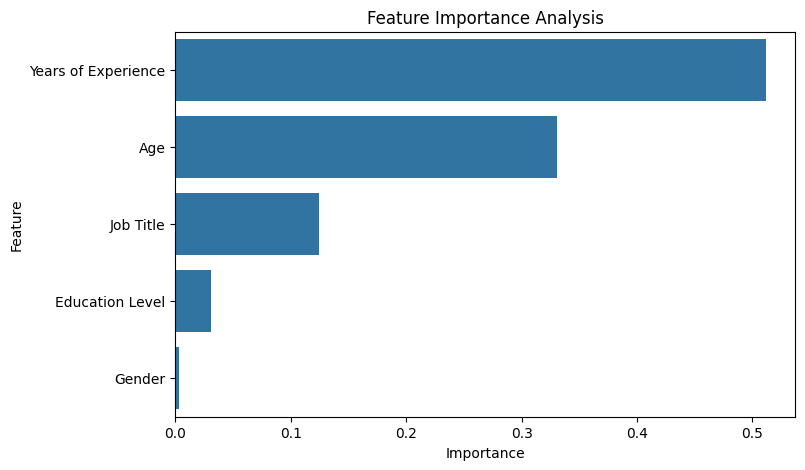

In [75]:
#Graph 
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance Analysis")

plt.show()

In [76]:
import joblib

In [77]:
joblib.dump(
    rf_model,
    "../models/salary_model.pkl"
)

['../models/salary_model.pkl']

In [80]:
#testing model save or not

loaded_model = joblib.load(
    "../models/salary_model.pkl"
)

In [81]:
loaded_model.predict(X_test.head(1))

array([107950.])

Save Encoders

In [82]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_cols = [
    "Gender",
    "Education Level",
    "Job Title"
]

for col in categorical_cols:
    le = LabelEncoder()

    le.fit(df[col])

    encoders[col] = le



In [85]:
#Saving Encoders

joblib.dump(
    encoders,
    "../models/encoders.pkl"
)

['../models/encoders.pkl']

In [86]:
#Test Load

saved_encoders = joblib.load(
    "../models/encoders.pkl"
)

In [87]:
#Test

saved_encoders["Gender"].classes_

array([0, 1])

In [88]:
df_original = pd.read_csv("../data/Salary Data.csv")

In [89]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_cols = [
    "Gender",
    "Education Level",
    "Job Title"
]

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df_original[col])
    encoders[col] = le

In [90]:
joblib.dump(
    encoders,
    "../models/encoders.pkl"
)

['../models/encoders.pkl']

In [91]:
saved_encoders = joblib.load(
    "../models/encoders.pkl"
)

saved_encoders["Gender"].classes_

array(['Female', 'Male', nan], dtype=object)

In [92]:
saved_encoders["Education Level"].classes_

array(["Bachelor's", "Master's", 'PhD', nan], dtype=object)

```Final Prediction Pipeline```

```Loading Model aur Encoder```

In [94]:
model = joblib.load("../models/salary_model.pkl")

encoders = joblib.load("../models/encoders.pkl")

In [ ]:
#creating employee data

employee_data = {
    "Age": 28,
    "Gender": "Male",
    "Education Level": "Master's",
    "Job Title": "Data Scientist",
    "Years of Experience": 4
}

In [96]:
input_data = pd.DataFrame([employee_data])

input_data

,Age,Gender,Education Level,Job Title,Years of Experience
0,28,Male,Master's,Data Scientist,4


In [97]:
#Text to Encode

for col in categorical_cols:
    input_data[col] = encoders[col].transform(
        input_data[col]
    )

In [ ]:
#checks

input_data

,Age,Gender,Education Level,Job Title,Years of Experience
0,28,1,1,19,4


In [107]:
#Salary Prediction

prediction = model.predict(input_data)

print(
    "Predicted Salary:",
    prediction[0]
)


Predicted Salary: 67550.0
